<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Zadanie
- Wyznacz model regresji liniowej dla zestawienia "Y house price of unit area" od "X2 house age" w datasecie "estate.csv"
- zbadaj poziom korelacji za pomocą metryki r2

In [84]:
df = pd.read_csv('data/estate.csv')

In [85]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [86]:
model = LinearRegression()
model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()


In [87]:
x = df[df["Y house price of unit area"] < 100][["X2 house age"]].to_numpy()
y = df[df["Y house price of unit area"] < 100]["Y house price of unit area"].to_numpy().reshape(-1,1)


In [88]:
df["Y house price of unit area"] < 100

0      True
1      True
2      True
3      True
4      True
       ... 
409    True
410    True
411    True
412    True
413    True
Name: Y house price of unit area, Length: 414, dtype: bool

In [102]:
x1 = df[df["Y house price of unit area"] < 100][["X2 house age", "X3 distance to the nearest MRT station"]].to_numpy()
x2 = df[df["Y house price of unit area"] < 100][["X2 house age", "X3 distance to the nearest MRT station", "X4 number of convenience stores"]].to_numpy()
x3 = df[df["Y house price of unit area"] < 100][["X2 house age", "X3 distance to the nearest MRT station", "X4 number of convenience stores", "X5 latitude"]].to_numpy()
y = df[df["Y house price of unit area"] < 100]["Y house price of unit area"].to_numpy().reshape(-1,1)

In [108]:
model1.fit(x1,y)
model2.fit(x2,y)
model3.fit(x3,y)


LinearRegression()

In [109]:
r_sq1 = model1.score(x1,y)
r_sq2 = model2.score(x2,y)
r_sq3 = model3.score(x3,y)

In [107]:
print(r_sq1, r_sq2, r_sq3)

0.5192528870554896 0.5858495586673387 0.6167835756597958


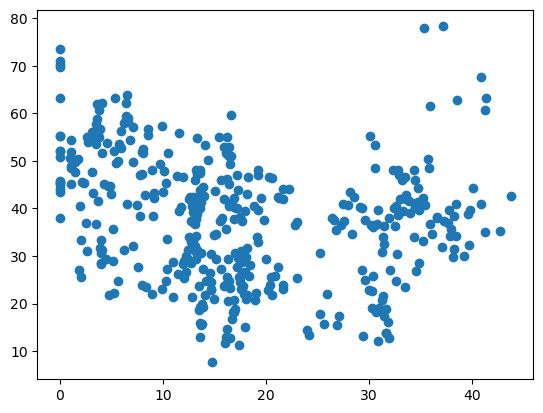

In [93]:
plt.scatter(x,y)
plt.show()

In [94]:
y_pred = model.predict(x)

NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

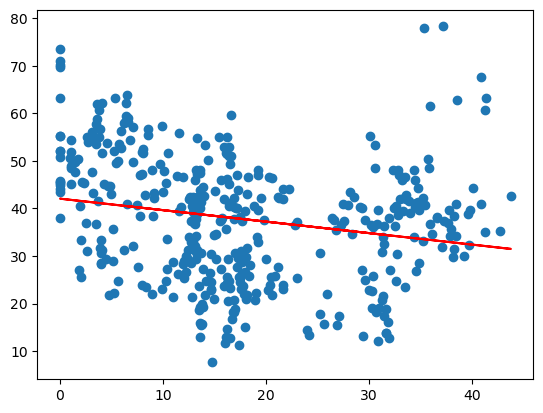

In [ ]:
plt.scatter(x,y)
plt.plot(x,y_pred, "r")
plt.show()

In [ ]:
r_sq = model.score(x,y)
r_sq

0.6169809884756035

In [ ]:
data = y
mean = np.mean(data)
std = np.std(data)
threshold = 3
outliers = []
for x in data:
    z_score = (x - mean) / std
    if abs(z_score) > threshold:
        outliers.append(x)
print("Mean: ",mean)
print("\nStandard deviation: ",std)
print("\nOutliers  : ", outliers)
new_data =  [y for y in data if y not in outliers]
new_data

Mean:  37.980193236714975

Standard deviation:  13.590044806293161

Outliers  :  [array([117.5])]


[array([37.9]),
 array([42.2]),
 array([47.3]),
 array([54.8]),
 array([43.1]),
 array([32.1]),
 array([40.3]),
 array([46.7]),
 array([18.8]),
 array([22.1]),
 array([41.4]),
 array([58.1]),
 array([39.3]),
 array([23.8]),
 array([34.3]),
 array([50.5]),
 array([70.1]),
 array([37.4]),
 array([42.3]),
 array([47.7]),
 array([29.3]),
 array([51.6]),
 array([24.6]),
 array([47.9]),
 array([38.8]),
 array([27.]),
 array([56.2]),
 array([33.6]),
 array([47.]),
 array([57.1]),
 array([22.1]),
 array([25.]),
 array([34.2]),
 array([49.3]),
 array([55.1]),
 array([27.3]),
 array([22.9]),
 array([25.3]),
 array([47.7]),
 array([46.2]),
 array([15.9]),
 array([18.2]),
 array([34.7]),
 array([34.1]),
 array([53.9]),
 array([38.3]),
 array([42.]),
 array([61.5]),
 array([13.4]),
 array([13.2]),
 array([44.2]),
 array([20.7]),
 array([27.]),
 array([38.9]),
 array([51.7]),
 array([13.7]),
 array([41.9]),
 array([53.5]),
 array([22.6]),
 array([42.4]),
 array([21.3]),
 array([63.2]),
 array([27.7]

In [ ]:
outliers[0][0]

117.5

In [ ]:
df = df[df["X2 house age"] != outliers[0][0]]

In [ ]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
x1 = df["X2 house age"].to_numpy().reshape(-1,1)
y1 = df["Y house price of unit area"].to_numpy().reshape(-1,1)

In [ ]:
model.fit(x1,y1)

LinearRegression()

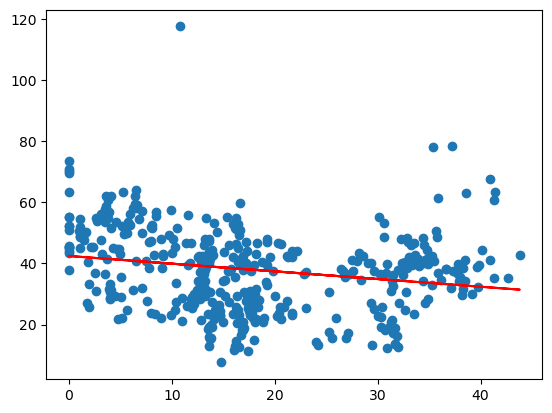

In [ ]:
plt.scatter(x1,y1)
plt.plot(x1,y_pred, "r")
plt.show()

ValueError: x and y must be the same size

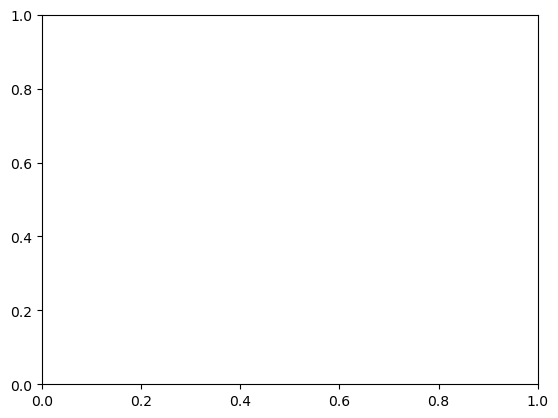

In [ ]:
plt.scatter(x,new_data)
plt.plot(x,y_pred, "r")
plt.show()